###SECTION 1 — Business Understanding

# Retail Sales, Customer & Profitability Analytics

**1. Business Understanding**

**1.1 Business Objective**

This project analyzes retail transaction data to evaluate sales performance and profitability, understand customer contribution, and identify product return patterns.

The analysis is structured around four analytical pillars:

1. Sales Performance
2. Profitability & Pricing
3. Customer Value
4. Returns

The objective is to transform transactional data into actionable business insights that can support decision-making related to sales performance, pricing, customer strategy, and product returns.

**1.2 Business Questions**

**Pillar 1 — Sales Performance**

1. How do revenue and profit change over time?
2. Which product categories contribute the most revenue and profit?

**Pillar 2 — Profitability & Pricing**

3. How does discounting relate to revenue and profitability?
4. Which products or categories generate high revenue but relatively low profit margins?

**Pillar 3 — Customer Value**

5. Which customer segments contribute the most revenue and profit?
6. How does customer contribution vary across regions?

**Pillar 4 — Returns**

7. Which product categories have the highest return rates?
8. What are the most common return reasons, and how are they distributed across product categories?



**1.3 Key Performance Indicators**

The analysis will use the following key metrics:

| KPI | Description |
|---|---|
| Total Revenue | Realized sales after discount, excluding returned items |
| Gross Profit | Realized Revenue − Cost |
| Profit Margin | Gross Profit / Realized Revenue |
| Total Orders | Distinct OrderID |
| Total Customers | Distinct CustomerID |
| Average Order Value (AOV) | Realized Revenue / Total Orders |
| Return Rate | Returned order details / Total order details |
| Quantity Sold | Total quantity of products sold |

###SECTION 2 — Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving categories.csv to categories.csv
Saving customers.csv to customers.csv
Saving order_details.csv to order_details.csv
Saving orders.csv to orders.csv
Saving products.csv to products.csv


In [ ]:
categories = pd.read_csv("categories.csv")
products = pd.read_csv("products.csv")
customers = pd.read_csv("customers.csv")
orders = pd.read_csv("orders.csv")
order_details = pd.read_csv("order_details.csv")

In [ ]:
datasets = {
    "categories": categories,
    "products": products,
    "customers": customers,
    "orders": orders,
    "order_details": order_details
}

for name, df in datasets.items():
    print(f"{name:15} : {df.shape[0]:,} rows × {df.shape[1]} columns")

categories      : 10 rows × 2 columns
products        : 100 rows × 3 columns
customers       : 1,000 rows × 7 columns
orders          : 10,000 rows × 4 columns
order_details   : 30,271 rows × 10 columns


###SECTION 3 — Data Understanding

**3. Data Understanding**

The dataset consists of five relational tables representing the main components of a retail transaction system:

- `categories`: Product category master data
- `products`: Product master data
- `customers`: Customer demographic and segmentation data
- `orders`: Transaction-level order data
- `order_details`: Product-level details within each order

The tables are connected through primary and foreign key relationships and will be integrated during the analysis stage.

In [ ]:
summary = pd.DataFrame({
    "Table": datasets.keys(),
    "Rows": [df.shape[0] for df in datasets.values()],
    "Columns": [df.shape[1] for df in datasets.values()]
})

summary

,Table,Rows,Columns
0,categories,10,2
1,products,100,3
2,customers,1000,7
3,orders,10000,4
4,order_details,30271,10


In [ ]:
for name, df in datasets.items():
    print("=" * 70)
    print(f"{name.upper()}")
    print("=" * 70)
    print(df.columns.tolist())
    print()

CATEGORIES
['CategoryID', 'CategoryName']

PRODUCTS
['ProductID', 'ProductName', 'CategoryID']

CUSTOMERS
['CustomerID', 'Gender', 'Age', 'City', 'Region', 'CustomerSegment', 'SignUpDate']

ORDERS
['OrderID', 'CustomerID', 'OrderDate', 'OrderTime']

ORDER_DETAILS
['OrderID', 'ProductID', 'Quantity', 'UnitCost', 'UnitPrice', 'DiscountRate', 'IsReturned', 'ReturnDate', 'ReturnTime', 'ReturnReason']



In [ ]:
for name, df in datasets.items():
    print(f"\n{'=' * 70}")
    print(f"{name.upper()}")
    print("=" * 70)
    display(df.head())


CATEGORIES


,CategoryID,CategoryName
0,CTGRY0001,Meat & Poultry
1,CTGRY0002,Dairy & Eggs
2,CTGRY0003,Produce
3,CTGRY0004,Beverages
4,CTGRY0005,Bakery



PRODUCTS


,ProductID,ProductName,CategoryID
0,PRDCT0001,ABC's Beef Ribeye,CTGRY0001
1,PRDCT0002,XYZ's Chicken Breast,CTGRY0001
2,PRDCT0003,KLM's Turkey Breast,CTGRY0001
3,PRDCT0004,ABC's Lamb Chops,CTGRY0001
4,PRDCT0005,XYZ's Atlantic Salmon,CTGRY0001



CUSTOMERS


,CustomerID,Gender,Age,City,Region,CustomerSegment,SignUpDate
0,CSTMR0001,Male,29,Istanbul,Marmara,Standard,2020-04-13
1,CSTMR0002,Other,40,Istanbul,Marmara,Standard,2020-04-08
2,CSTMR0003,Female,36,Bursa,Marmara,Premium,2022-08-14
3,CSTMR0004,Male,18,Istanbul,Marmara,Premium,2022-03-26
4,CSTMR0005,Male,43,Izmir,Aegean,Premium,2021-04-04



ORDERS


,OrderID,CustomerID,OrderDate,OrderTime
0,ORD00001,CSTMR0983,2021-04-10,12:53:24
1,ORD00002,CSTMR0703,2024-04-21,22:08:16
2,ORD00003,CSTMR0920,2022-10-27,10:21:26
3,ORD00004,CSTMR0158,2025-11-07,22:24:27
4,ORD00005,CSTMR0834,2021-09-05,13:23:16



ORDER_DETAILS


,OrderID,ProductID,Quantity,UnitCost,UnitPrice,DiscountRate,IsReturned,ReturnDate,ReturnTime,ReturnReason
0,ORD00001,PRDCT0056,3,2.14,3.38,0.00,0,9999-12-31,00:00:00,NaN
1,ORD00002,PRDCT0028,2,4.17,5.31,0.00,0,9999-12-31,00:00:00,NaN
2,ORD00002,PRDCT0001,13,20.36,25.77,0.05,0,9999-12-31,00:00:00,NaN
3,ORD00003,PRDCT0030,2,0.90,1.35,0.00,0,9999-12-31,00:00:00,NaN
4,ORD00004,PRDCT0003,3,12.84,20.35,0.00,0,9999-12-31,00:00:00,NaN


In [ ]:
for name, df in datasets.items():
    print(f"\n{'=' * 70}")
    print(f"{name.upper()}")
    print("=" * 70)
    display(df.dtypes.to_frame("Data Type"))


CATEGORIES


,Data Type
CategoryID,object
CategoryName,object



PRODUCTS


,Data Type
ProductID,object
ProductName,object
CategoryID,object



CUSTOMERS


,Data Type
CustomerID,object
Gender,object
Age,int64
City,object
Region,object
CustomerSegment,object
SignUpDate,object



ORDERS


,Data Type
OrderID,object
CustomerID,object
OrderDate,object
OrderTime,object



ORDER_DETAILS


,Data Type
OrderID,object
ProductID,object
Quantity,int64
UnitCost,float64
UnitPrice,float64
DiscountRate,float64
IsReturned,int64
ReturnDate,object
ReturnTime,object
ReturnReason,object


In [ ]:
for name, df in datasets.items():
    print(f"\n{name.upper()}")
    display(df.describe().T)


CATEGORIES


,count,unique,top,freq
CategoryID,10,10,CTGRY0001,1
CategoryName,10,10,Meat & Poultry,1



PRODUCTS


,count,unique,top,freq
ProductID,100,100,PRDCT0001,1
ProductName,100,100,ABC's Beef Ribeye,1
CategoryID,100,10,CTGRY0001,10



CUSTOMERS


,count,mean,std,min,25%,50%,75%,max
Age,"1,000.00",38.16,11.44,18.00,29.00,38.00,46.00,72.00



ORDERS


,count,unique,top,freq
OrderID,10000,10000,ORD10000,1
CustomerID,10000,1000,CSTMR0712,22
OrderDate,10000,1922,2024-04-21,17
OrderTime,10000,9019,19:20:14,4



ORDER_DETAILS


,count,mean,std,min,25%,50%,75%,max
Quantity,"30,271.00",2.68,3.27,1.00,1.00,2.00,3.00,25.00
UnitCost,"30,271.00",6.80,5.55,0.82,3.04,5.14,8.94,32.81
UnitPrice,"30,271.00",9.79,7.96,1.17,4.50,7.44,12.68,49.62
DiscountRate,"30,271.00",0.04,0.07,0.00,0.00,0.00,0.05,0.40
IsReturned,"30,271.00",0.05,0.21,0.00,0.00,0.00,0.00,1.00


In [ ]:
orders[["OrderDate"]].head()

,OrderDate
0,2021-04-10
1,2024-04-21
2,2022-10-27
3,2025-11-07
4,2021-09-05


In [ ]:
orders["OrderDate"].min(), orders["OrderDate"].max()

('2021-01-01', '2026-06-01')

###SECTION 4 - Data Quality & Data Preparation

In [ ]:
missing_summary = []

for name, df in datasets.items():
    missing_count = df.isna().sum()
    missing_percent = (missing_count / len(df)) * 100

    temp = pd.DataFrame({
        "Table": name,
        "Column": df.columns,
        "Missing Values": missing_count.values,
        "Missing (%)": missing_percent.values
    })

    missing_summary.append(temp)

missing_summary = pd.concat(missing_summary, ignore_index=True)

missing_summary[missing_summary["Missing Values"] > 0]

,Table,Column,Missing Values,Missing (%)
25,order_details,ReturnReason,28847,95.30


In [ ]:
duplicate_summary = []

for name, df in datasets.items():
    duplicate_count = df.duplicated().sum()

    duplicate_summary.append({
        "Table": name,
        "Duplicate Rows": duplicate_count
    })

duplicate_summary = pd.DataFrame(duplicate_summary)

duplicate_summary

,Table,Duplicate Rows
0,categories,0
1,products,0
2,customers,0
3,orders,0
4,order_details,0


In [ ]:
primary_keys = {
    "categories": ["CategoryID"],
    "products": ["ProductID"],
    "customers": ["CustomerID"],
    "orders": ["OrderID"],
    "order_details": ["OrderID", "ProductID"]
}

pk_results = []

for table, keys in primary_keys.items():
    df = datasets[table]

    duplicate_pk = df.duplicated(subset=keys).sum()

    pk_results.append({
        "Table": table,
        "Primary Key": " + ".join(keys),
        "Duplicate Keys": duplicate_pk
    })

pk_results = pd.DataFrame(pk_results)

pk_results

,Table,Primary Key,Duplicate Keys
0,categories,CategoryID,0
1,products,ProductID,0
2,customers,CustomerID,0
3,orders,OrderID,0
4,order_details,OrderID + ProductID,0


In [ ]:
referential_checks = {
    "products → categories": (
        products["CategoryID"],
        categories["CategoryID"]
    ),
    "orders → customers": (
        orders["CustomerID"],
        customers["CustomerID"]
    ),
    "order_details → orders": (
        order_details["OrderID"],
        orders["OrderID"]
    ),
    "order_details → products": (
        order_details["ProductID"],
        products["ProductID"]
    )
}

fk_results = []

for relationship, (child_key, parent_key) in referential_checks.items():
    orphan_count = (~child_key.isin(parent_key)).sum()

    fk_results.append({
        "Relationship": relationship,
        "Orphan Records": orphan_count
    })

fk_results = pd.DataFrame(fk_results)

fk_results

,Relationship,Orphan Records
0,products → categories,0
1,orders → customers,0
2,order_details → orders,0
3,order_details → products,0


In [ ]:
quantity_check = (order_details["Quantity"] <= 0).sum()

print(f"Records with Quantity <= 0: {quantity_check}")

Records with Quantity <= 0: 0


In [ ]:
unit_cost_check = (order_details["UnitCost"] <= 0).sum()

print(f"Records with UnitCost <= 0: {unit_cost_check}")

Records with UnitCost <= 0: 0


In [ ]:
unit_price_check = (order_details["UnitPrice"] <= 0).sum()

print(f"Records with UnitPrice <= 0: {unit_price_check}")

Records with UnitPrice <= 0: 0


In [ ]:
print("Minimum:", order_details["DiscountRate"].min())
print("Maximum:", order_details["DiscountRate"].max())

Minimum: 0.0
Maximum: 0.4


In [ ]:
discount_check = (
    (order_details["DiscountRate"] < 0) |
    (order_details["DiscountRate"] > 1)
).sum()

print(f"Records with invalid DiscountRate: {discount_check}")

Records with invalid DiscountRate: 0


In [ ]:
returned_values = order_details["IsReturned"].unique()

print("Unique IsReturned values:", sorted(returned_values))

Unique IsReturned values: [np.int64(0), np.int64(1)]


In [ ]:
invalid_return_flag = (
    ~order_details["IsReturned"].isin([0, 1])
).sum()

print(f"Invalid IsReturned values: {invalid_return_flag}")

Invalid IsReturned values: 0


In [ ]:
customers["SignUpDate"] = pd.to_datetime(
    customers["SignUpDate"],
    errors="coerce"
)

orders["OrderDate"] = pd.to_datetime(
    orders["OrderDate"],
    errors="coerce"
)

order_details["ReturnDate"] = pd.to_datetime(
    order_details["ReturnDate"],
    errors="coerce"
)

/tmp/ipykernel_1766/2287691169.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  order_details["ReturnDate"] = pd.to_datetime(


In [ ]:
orders["OrderTime"] = pd.to_datetime(
    orders["OrderTime"],
    format="%H:%M:%S",
    errors="coerce"
).dt.time

order_details["ReturnTime"] = pd.to_datetime(
    order_details["ReturnTime"],
    format="%H:%M:%S",
    errors="coerce"
).dt.time

In [ ]:
datetime_checks = {
    "customers.SignUpDate": customers["SignUpDate"].isna().sum(),
    "orders.OrderDate": orders["OrderDate"].isna().sum(),
    "order_details.ReturnDate": order_details["ReturnDate"].isna().sum()
}

pd.DataFrame(
    datetime_checks.items(),
    columns=["Column", "Invalid / Missing After Conversion"]
)

,Column,Invalid / Missing After Conversion
0,customers.SignUpDate,0
1,orders.OrderDate,0
2,order_details.ReturnDate,28847


In [ ]:
customer_order_check = orders.merge(
    customers[["CustomerID", "SignUpDate"]],
    on="CustomerID",
    how="left"
)

invalid_signup_orders = (
    customer_order_check["OrderDate"] <
    customer_order_check["SignUpDate"]
).sum()

print(
    f"Orders occurring before customer signup date: "
    f"{invalid_signup_orders}"
)

Orders occurring before customer signup date: 0


In [ ]:
return_check = order_details.merge(
    orders[["OrderID", "OrderDate"]],
    on="OrderID",
    how="left"
)

returned_records = return_check[
    return_check["IsReturned"] == 1
].copy()

invalid_return_dates = (
    returned_records["ReturnDate"] <
    returned_records["OrderDate"]
).sum()

print(
    f"Returned records with ReturnDate before OrderDate: "
    f"{invalid_return_dates}"
)

Returned records with ReturnDate before OrderDate: 0


In [ ]:
quality_summary = pd.DataFrame({
    "Check": [
        "Missing Values",
        "Duplicate Rows",
        "Duplicate Primary Keys",
        "Orphan Foreign Keys",
        "Invalid Quantity",
        "Invalid Unit Cost",
        "Invalid Unit Price",
        "Invalid Discount Rate",
        "Invalid IsReturned",
        "Orders Before Customer Signup",
        "Returns Before Order Date"
    ],
    "Status": [
        "Review above",
        duplicate_summary["Duplicate Rows"].sum(),
        pk_results["Duplicate Keys"].sum(),
        fk_results["Orphan Records"].sum(),
        quantity_check,
        unit_cost_check,
        unit_price_check,
        discount_check,
        invalid_return_flag,
        invalid_signup_orders,
        invalid_return_dates
    ]
})

quality_summary

,Check,Status
0,Missing Values,Review above
1,Duplicate Rows,0
2,Duplicate Primary Keys,0
3,Orphan Foreign Keys,0
4,Invalid Quantity,0
5,Invalid Unit Cost,0
6,Invalid Unit Price,0
7,Invalid Discount Rate,0
8,Invalid IsReturned,0
9,Orders Before Customer Signup,0


In [ ]:
return_reason_check = pd.crosstab(
    order_details["IsReturned"],
    order_details["ReturnReason"],
    dropna=False
)

return_reason_check

ReturnReason,Broken Package/Leaks,Bruised/Damaged,Crushed Package,Crushed/Broken,Customer Changed Mind,Damaged Can,Damaged Seal,Damaged Spray Nozzle,Expired Date,Freezer Burn,Leaking Bottle,Leaking Chemical,Leaking/Broken Pump,Molded,Molded/Rotten,Packaging Damage,Packaging Defect,Quality Dissatisfaction,Skin Irritation/Allergy,Spoiled/Expired,Stale/Hard,Strong Odor Issue,Taste Defect,Thawed/Melted,Unpleasant Odor,Unripe Product,Wrong Flavor Sent,Wrong Item Sent,Wrong Product Sent,NaN
IsReturned,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,28847
1,20,17,20,37,299,39,32,43,156,20,37,32,30,28,21,48,65,23,29,25,30,43,21,8,22,30,67,114,68,0


In [ ]:
order_details.groupby(
    "IsReturned",
    dropna=False
)["ReturnReason"].apply(
    lambda x: x.isna().sum()
).reset_index(name="Missing ReturnReason")

,IsReturned,Missing ReturnReason
0,0,28847
1,1,0


In [ ]:
order_details[
    order_details["IsReturned"] == 1
]["ReturnReason"].value_counts(dropna=False)

,count
ReturnReason,
Customer Changed Mind,299
Expired Date,156
Wrong Item Sent,114
Wrong Product Sent,68
Wrong Flavor Sent,67
Packaging Defect,65
Packaging Damage,48
Damaged Spray Nozzle,43
Strong Odor Issue,43


The dataset passed the data quality validation with no critical integrity or business rule violations. The 28,847 missing values in ReturnReason were identified as structural missingness because the field is not applicable to non returned items. All returned items have a corresponding return reason. Therefore, no records were removed or imputed during data preparation. Date and time fields were converted into appropriate datetime formats for subsequent analysis.

###Section 5 — SQL Business Analysis

**5. SQL Business Analysis**

SQL is used to analyze the relational retail dataset and answer the defined business questions. The five source tables are loaded into a SQLite database to replicate a relational analytical environment.

The analysis focuses on four analytical pillars:

1. Sales Performance
2. Profitability & Pricing
3. Customer Value
4. Returns

In [ ]:
import sqlite3

# Create an in-memory SQLite database
conn = sqlite3.connect(":memory:")

# Load DataFrames into SQLite tables
categories.to_sql("categories", conn, index=False, if_exists="replace")
products.to_sql("products", conn, index=False, if_exists="replace")
customers.to_sql("customers", conn, index=False, if_exists="replace")
orders.to_sql("orders", conn, index=False, if_exists="replace")
order_details.to_sql("order_details", conn, index=False, if_exists="replace")

print("SQLite database created successfully.")

SQLite database created successfully.


**5.2 Validate SQL Tables**

In [ ]:
tables = pd.read_sql_query("""
SELECT name
FROM sqlite_master
WHERE type = 'table'
ORDER BY name;
""", conn)

tables

,name
0,categories
1,customers
2,order_details
3,orders
4,products


In [ ]:
row_counts = pd.read_sql_query("""
SELECT 'categories' AS table_name, COUNT(*) AS row_count
FROM categories

UNION ALL

SELECT 'products', COUNT(*)
FROM products

UNION ALL

SELECT 'customers', COUNT(*)
FROM customers

UNION ALL

SELECT 'orders', COUNT(*)
FROM orders

UNION ALL

SELECT 'order_details', COUNT(*)
FROM order_details;
""", conn)

row_counts

,table_name,row_count
0,categories,10
1,products,100
2,customers,1000
3,orders,10000
4,order_details,30271


**5.3 Analytical Dataset**

The relational tables are joined to create an analytical dataset at the order-detail level.

Each row represents one product line within an order. Customer, product, category, transaction, pricing, discount, and return information are integrated into a single analytical view.

The dataset is maintained at the order-detail grain to avoid losing product-level information required for profitability and return analysis.

In [ ]:
master_query = """
SELECT
    o.OrderID,
    o.OrderDate,
    o.OrderTime,

    c.CustomerID,
    c.Gender,
    c.Age,
    c.City,
    c.Region,
    c.CustomerSegment,
    c.SignUpDate,

    p.ProductID,
    p.ProductName,

    cat.CategoryID,
    cat.CategoryName,

    od.Quantity,
    od.UnitCost,
    od.UnitPrice,
    od.DiscountRate,

    od.IsReturned,
    od.ReturnDate,
    od.ReturnTime,
    od.ReturnReason

FROM orders AS o

INNER JOIN customers AS c
    ON o.CustomerID = c.CustomerID

INNER JOIN order_details AS od
    ON o.OrderID = od.OrderID

INNER JOIN products AS p
    ON od.ProductID = p.ProductID

INNER JOIN categories AS cat
    ON p.CategoryID = cat.CategoryID
"""

In [ ]:
master_df = pd.read_sql_query(master_query, conn)

master_df.head()

,OrderID,OrderDate,OrderTime,CustomerID,Gender,Age,City,Region,CustomerSegment,SignUpDate,ProductID,ProductName,CategoryID,CategoryName,Quantity,UnitCost,UnitPrice,DiscountRate,IsReturned,ReturnDate,ReturnTime,ReturnReason
0,ORD00001,2021-04-10 00:00:00,12:53:24.000000,CSTMR0983,Male,59,Istanbul,Marmara,Standard,2020-10-20 00:00:00,PRDCT0056,VWX's Salted Pretzels,CTGRY0006,Snacks,3,2.14,3.38,0.00,0,None,00:00:00.000000,None
1,ORD00002,2024-04-21 00:00:00,22:08:16.000000,CSTMR0703,Female,47,Istanbul,Marmara,Standard,2020-11-06 00:00:00,PRDCT0001,ABC's Beef Ribeye,CTGRY0001,Meat & Poultry,13,20.36,25.77,0.05,0,None,00:00:00.000000,None
2,ORD00002,2024-04-21 00:00:00,22:08:16.000000,CSTMR0703,Female,47,Istanbul,Marmara,Standard,2020-11-06 00:00:00,PRDCT0028,XYZ's Broccoli Crowns,CTGRY0003,Produce,2,4.17,5.31,0.00,0,None,00:00:00.000000,None
3,ORD00003,2022-10-27 00:00:00,10:21:26.000000,CSTMR0920,Male,34,Ankara,Central Anatolia,Standard,2022-04-15 00:00:00,PRDCT0030,ABC's Blueberries,CTGRY0003,Produce,2,0.90,1.35,0.00,0,None,00:00:00.000000,None
4,ORD00004,2025-11-07 00:00:00,22:24:27.000000,CSTMR0158,Male,35,Ankara,Central Anatolia,VIP,2021-01-08 00:00:00,PRDCT0003,KLM's Turkey Breast,CTGRY0001,Meat & Poultry,3,12.84,20.35,0.00,0,None,00:00:00.000000,None


**5.4 Validate Analytical Dataset**

In [ ]:
print(f"Rows in analytical dataset: {len(master_df):,}")

Rows in analytical dataset: 30,271


In [ ]:
print(f"Unique Orders: {master_df['OrderID'].nunique():,}")

Unique Orders: 10,000


In [ ]:
print(f"Unique Customers: {master_df['CustomerID'].nunique():,}")

Unique Customers: 1,000


In [ ]:
print(f"Unique Products: {master_df['ProductID'].nunique():,}")

Unique Products: 100


**5.5 Create Business Metrics with SQL**

In [ ]:
metrics_query = """
SELECT
    o.OrderID,
    o.OrderDate,

    c.CustomerID,
    c.CustomerSegment,
    c.Region,

    p.ProductID,
    p.ProductName,
    cat.CategoryName,

    od.Quantity,
    od.UnitCost,
    od.UnitPrice,
    od.DiscountRate,
    od.IsReturned,
    od.ReturnReason,

    -- Sales metrics
    od.Quantity * od.UnitPrice AS GrossSales,

    od.Quantity * od.UnitPrice * od.DiscountRate
        AS DiscountAmount,

    od.Quantity * od.UnitPrice
        * (1 - od.DiscountRate)
        AS NetSales,

    -- Cost and profit
    od.Quantity * od.UnitCost
        AS TotalCost,

    (
        od.Quantity * od.UnitPrice * (1 - od.DiscountRate)
        - od.Quantity * od.UnitCost
    ) AS Profit,

    -- Realized metrics after excluding returned items
    CASE
        WHEN od.IsReturned = 0 THEN
            od.Quantity * od.UnitPrice * (1 - od.DiscountRate)
        ELSE 0
    END AS RealizedRevenue,

    CASE
        WHEN od.IsReturned = 0 THEN
            (
                od.Quantity * od.UnitPrice * (1 - od.DiscountRate)
                - od.Quantity * od.UnitCost
            )
        ELSE 0
    END AS RealizedProfit

FROM orders AS o

INNER JOIN customers AS c
    ON o.CustomerID = c.CustomerID

INNER JOIN order_details AS od
    ON o.OrderID = od.OrderID

INNER JOIN products AS p
    ON od.ProductID = p.ProductID

INNER JOIN categories AS cat
    ON p.CategoryID = cat.CategoryID
"""

In [ ]:
metrics_df = pd.read_sql_query(metrics_query, conn)

metrics_df.head()

,OrderID,OrderDate,CustomerID,CustomerSegment,Region,ProductID,ProductName,CategoryName,Quantity,UnitCost,UnitPrice,DiscountRate,IsReturned,ReturnReason,GrossSales,DiscountAmount,NetSales,TotalCost,Profit,RealizedRevenue,RealizedProfit
0,ORD00001,2021-04-10 00:00:00,CSTMR0983,Standard,Marmara,PRDCT0056,VWX's Salted Pretzels,Snacks,3,2.14,3.38,0.00,0,None,10.14,0.00,10.14,6.42,3.72,10.14,3.72
1,ORD00002,2024-04-21 00:00:00,CSTMR0703,Standard,Marmara,PRDCT0001,ABC's Beef Ribeye,Meat & Poultry,13,20.36,25.77,0.05,0,None,335.01,16.75,318.26,264.68,53.58,318.26,53.58
2,ORD00002,2024-04-21 00:00:00,CSTMR0703,Standard,Marmara,PRDCT0028,XYZ's Broccoli Crowns,Produce,2,4.17,5.31,0.00,0,None,10.62,0.00,10.62,8.34,2.28,10.62,2.28
3,ORD00003,2022-10-27 00:00:00,CSTMR0920,Standard,Central Anatolia,PRDCT0030,ABC's Blueberries,Produce,2,0.90,1.35,0.00,0,None,2.70,0.00,2.70,1.80,0.90,2.70,0.90
4,ORD00004,2025-11-07 00:00:00,CSTMR0158,VIP,Central Anatolia,PRDCT0003,KLM's Turkey Breast,Meat & Poultry,3,12.84,20.35,0.00,0,None,61.05,0.00,61.05,38.52,22.53,61.05,22.53


**5.6 Validate Calculated Metrics**

In [ ]:
metrics_df[
    [
        "Quantity",
        "UnitCost",
        "UnitPrice",
        "DiscountRate",
        "GrossSales",
        "DiscountAmount",
        "NetSales",
        "TotalCost",
        "Profit",
        "RealizedRevenue",
        "RealizedProfit"
    ]
].head(10)

,Quantity,UnitCost,UnitPrice,DiscountRate,GrossSales,DiscountAmount,NetSales,TotalCost,Profit,RealizedRevenue,RealizedProfit
0,3,2.14,3.38,0.00,10.14,0.00,10.14,6.42,3.72,10.14,3.72
1,13,20.36,25.77,0.05,335.01,16.75,318.26,264.68,53.58,318.26,53.58
2,2,4.17,5.31,0.00,10.62,0.00,10.62,8.34,2.28,10.62,2.28
3,2,0.90,1.35,0.00,2.70,0.00,2.70,1.80,0.90,2.70,0.90
4,3,12.84,20.35,0.00,61.05,0.00,61.05,38.52,22.53,61.05,22.53
5,3,13.56,21.30,0.00,63.90,0.00,63.90,40.68,23.22,63.90,23.22
6,5,2.84,3.60,0.00,18.00,0.00,18.00,14.20,3.80,18.00,3.80
7,4,1.65,2.36,0.00,9.44,0.00,9.44,6.60,2.84,9.44,2.84
8,2,2.64,3.75,0.00,7.50,0.00,7.50,5.28,2.22,7.50,2.22
9,3,15.30,19.36,0.30,58.08,17.42,40.66,45.90,-5.24,40.66,-5.24


**5.7 Overall Business Performance**

In [ ]:
overall_kpi = pd.read_sql_query("""
SELECT
    COUNT(DISTINCT OrderID) AS TotalOrders,
    COUNT(DISTINCT CustomerID) AS TotalCustomers,
    SUM(Quantity) AS TotalQuantitySold,

    ROUND(SUM(RealizedRevenue), 2) AS TotalRevenue,
    ROUND(SUM(RealizedProfit), 2) AS GrossProfit,

    ROUND(
        SUM(RealizedProfit) / NULLIF(SUM(RealizedRevenue), 0) * 100,
        2
    ) AS ProfitMargin,

    ROUND(
        SUM(RealizedRevenue) /
        NULLIF(COUNT(DISTINCT OrderID), 0),
        2
    ) AS AverageOrderValue,

    SUM(
        CASE WHEN IsReturned = 1 THEN 1 ELSE 0 END
    ) AS ReturnedItems,

    ROUND(
        SUM(CASE WHEN IsReturned = 1 THEN 1 ELSE 0 END) * 100.0
        / COUNT(*),
        2
    ) AS ReturnRate

FROM (
    SELECT
        o.OrderID,
        c.CustomerID,
        od.Quantity,
        od.IsReturned,

        od.Quantity * od.UnitPrice * (1 - od.DiscountRate)
        AS RealizedRevenue,

        CASE
            WHEN od.IsReturned = 0 THEN
                (
                    od.Quantity * od.UnitPrice * (1 - od.DiscountRate)
                    - od.Quantity * od.UnitCost
                )
            ELSE 0
        END AS RealizedProfit

    FROM orders o

    JOIN customers c
        ON o.CustomerID = c.CustomerID

    JOIN order_details od
        ON o.OrderID = od.OrderID
)
""", conn)

overall_kpi

,TotalOrders,TotalCustomers,TotalQuantitySold,TotalRevenue,GrossProfit,ProfitMargin,AverageOrderValue,ReturnedItems,ReturnRate
0,10000,1000,81166,"761,951.13","202,204.37",26.54,76.20,1424,4.70


**5.8 Sales Performance — Monthly**

In [ ]:
monthly_sales = pd.read_sql_query("""
SELECT
    strftime('%Y-%m', OrderDate) AS Month,

    COUNT(DISTINCT OrderID) AS Orders,

    SUM(Quantity) AS QuantitySold,

    ROUND(SUM(RealizedRevenue), 2) AS Revenue,

    ROUND(SUM(RealizedProfit), 2) AS Profit,

    ROUND(
        SUM(RealizedProfit) /
        NULLIF(SUM(RealizedRevenue), 0) * 100,
        2
    ) AS ProfitMargin

FROM (
    SELECT
        o.OrderID,
        o.OrderDate,
        od.Quantity,
        od.IsReturned,

        CASE
            WHEN od.IsReturned = 0 THEN
                od.Quantity * od.UnitPrice * (1 - od.DiscountRate)
            ELSE 0
        END AS RealizedRevenue,

        CASE
            WHEN od.IsReturned = 0 THEN
                (
                    od.Quantity * od.UnitPrice * (1 - od.DiscountRate)
                    - od.Quantity * od.UnitCost
                )
            ELSE 0
        END AS RealizedProfit

    FROM orders o

    JOIN order_details od
        ON o.OrderID = od.OrderID
)

GROUP BY strftime('%Y-%m', OrderDate)

ORDER BY Month;
""", conn)

monthly_sales.head(10)

,Month,Orders,QuantitySold,Revenue,Profit,ProfitMargin
0,2021-01,52,445,"3,385.05",969.79,28.65
1,2021-02,50,521,"4,461.08","1,158.51",25.97
2,2021-03,51,362,"2,454.80",733.08,29.86
3,2021-04,71,663,"4,928.68","1,464.38",29.71
4,2021-05,73,545,"4,119.21","1,208.56",29.34
5,2021-06,60,479,"3,184.74",916.70,28.78
6,2021-07,69,454,"2,976.24",832.67,27.98
7,2021-08,76,654,"4,991.13","1,478.76",29.63
8,2021-09,78,751,"4,849.27","1,081.63",22.31
9,2021-10,87,613,"4,560.80","1,385.87",30.39


**5.9 Category Performance**

In [ ]:
category_performance = pd.read_sql_query("""
SELECT
    CategoryName,

    SUM(Quantity) AS QuantitySold,

    COUNT(DISTINCT OrderID) AS Orders,

    ROUND(SUM(RealizedRevenue), 2) AS Revenue,

    ROUND(SUM(RealizedProfit), 2) AS Profit,

    ROUND(
        SUM(RealizedProfit) /
        NULLIF(SUM(RealizedRevenue), 0) * 100,
        2
    ) AS ProfitMargin

FROM (
    SELECT
        o.OrderID,
        od.Quantity,
        od.IsReturned,
        cat.CategoryName,

        CASE
            WHEN od.IsReturned = 0 THEN
                od.Quantity * od.UnitPrice * (1 - od.DiscountRate)
            ELSE 0
        END AS RealizedRevenue,

        CASE
            WHEN od.IsReturned = 0 THEN
                (
                    od.Quantity * od.UnitPrice * (1 - od.DiscountRate)
                    - od.Quantity * od.UnitCost
                )
            ELSE 0
        END AS RealizedProfit

    FROM orders o

    JOIN order_details od
        ON o.OrderID = od.OrderID

    JOIN products p
        ON od.ProductID = p.ProductID

    JOIN categories cat
        ON p.CategoryID = cat.CategoryID
)

GROUP BY CategoryName

ORDER BY Revenue DESC;
""", conn)

category_performance

,CategoryName,QuantitySold,Orders,Revenue,Profit,ProfitMargin
0,Meat & Poultry,10463,2762,"244,949.24","65,503.69",26.74
1,Personal Care,7432,1931,"90,175.24","26,879.84",29.81
2,Household Cleaning,7710,2019,"80,547.45","25,291.57",31.40
3,Dairy & Eggs,10679,2834,"69,263.69","20,153.27",29.10
4,Pantry Staples,6997,1918,"50,895.40","13,154.30",25.85
5,Snacks,8402,2303,"48,935.78","13,518.84",27.63
6,Beverages,9020,2309,"40,970.32","11,868.40",28.97
7,Produce,11110,2809,"38,979.52","9,415.05",24.15
8,Frozen Foods,3671,1098,"36,135.49","8,866.71",24.54
9,Bakery,5682,1498,"27,620.99","7,552.71",27.34


**5.10 Revenue Contribution by Category**

In [ ]:
category_contribution = pd.read_sql_query("""
WITH category_sales AS (

    SELECT
        cat.CategoryName,

        SUM(
            CASE
                WHEN od.IsReturned = 0 THEN
                    od.Quantity * od.UnitPrice * (1 - od.DiscountRate)
                ELSE 0
            END
        ) AS Revenue

    FROM order_details od

    JOIN products p
        ON od.ProductID = p.ProductID

    JOIN categories cat
        ON p.CategoryID = cat.CategoryID

    GROUP BY cat.CategoryName
)

SELECT
    CategoryName,

    ROUND(Revenue, 2) AS Revenue,

    ROUND(
        Revenue * 100.0 /
        SUM(Revenue) OVER (),
        2
    ) AS RevenueContribution

FROM category_sales

ORDER BY Revenue DESC;
""", conn)

category_contribution

,CategoryName,Revenue,RevenueContribution
0,Meat & Poultry,"244,949.24",33.63
1,Personal Care,"90,175.24",12.38
2,Household Cleaning,"80,547.45",11.06
3,Dairy & Eggs,"69,263.69",9.51
4,Pantry Staples,"50,895.40",6.99
5,Snacks,"48,935.78",6.72
6,Beverages,"40,970.32",5.62
7,Produce,"38,979.52",5.35
8,Frozen Foods,"36,135.49",4.96
9,Bakery,"27,620.99",3.79


**5.11 Top Products by Revenue & Profit**

In [ ]:
product_performance = pd.read_sql_query("""
SELECT
    p.ProductID,
    p.ProductName,
    cat.CategoryName,

    SUM(od.Quantity) AS QuantitySold,

    ROUND(
        SUM(
            CASE
                WHEN od.IsReturned = 0 THEN
                    od.Quantity * od.UnitPrice
                    * (1 - od.DiscountRate)
                ELSE 0
            END
        ), 2
    ) AS Revenue,

    ROUND(
        SUM(
            CASE
                WHEN od.IsReturned = 0 THEN
                    (
                        od.Quantity * od.UnitPrice
                        * (1 - od.DiscountRate)
                        - od.Quantity * od.UnitCost
                    )
                ELSE 0
            END
        ), 2
    ) AS Profit

FROM order_details od

JOIN products p
    ON od.ProductID = p.ProductID

JOIN categories cat
    ON p.CategoryID = cat.CategoryID

GROUP BY
    p.ProductID,
    p.ProductName,
    cat.CategoryName

ORDER BY Revenue DESC;
""", conn)

product_performance.head(10)

,ProductID,ProductName,CategoryName,QuantitySold,Revenue,Profit
0,PRDCT0007,ABC's Ground Beef,Meat & Poultry,1019,"37,943.02","12,569.10"
1,PRDCT0002,XYZ's Chicken Breast,Meat & Poultry,1049,"35,223.34","8,493.41"
2,PRDCT0005,XYZ's Atlantic Salmon,Meat & Poultry,1092,"33,253.27","7,911.15"
3,PRDCT0010,ABC's Tuna Steak,Meat & Poultry,1058,"26,556.96","8,419.10"
4,PRDCT0009,KLM's Duck Breast,Meat & Poultry,1176,"25,414.22","6,821.49"
5,PRDCT0001,ABC's Beef Ribeye,Meat & Poultry,1075,"25,073.51","4,528.52"
6,PRDCT0008,XYZ's Beef Sausage,Meat & Poultry,1018,"17,926.47","6,000.22"
7,PRDCT0003,KLM's Turkey Breast,Meat & Poultry,974,"16,428.22","5,651.76"
8,PRDCT0078,DEF's Facial Cleanser,Personal Care,824,"15,637.54","5,138.20"
9,PRDCT0071,YZA's Liquid Hand Soap,Personal Care,825,"15,121.93","4,831.99"


**5.12 High Revenue but Low Margin**

In [ ]:
high_revenue_low_margin = pd.read_sql_query("""
SELECT
    ProductID,
    ProductName,
    CategoryName,
    Revenue,
    Profit,

    ROUND(
        Profit / NULLIF(Revenue, 0) * 100,
        2
    ) AS ProfitMargin

FROM (
    SELECT
        p.ProductID,
        p.ProductName,
        cat.CategoryName,

        SUM(
            CASE
                WHEN od.IsReturned = 0 THEN
                    od.Quantity * od.UnitPrice
                    * (1 - od.DiscountRate)
                ELSE 0
            END
        ) AS Revenue,

        SUM(
            CASE
                WHEN od.IsReturned = 0 THEN
                    (
                        od.Quantity * od.UnitPrice
                        * (1 - od.DiscountRate)
                        - od.Quantity * od.UnitCost
                    )
                ELSE 0
            END
        ) AS Profit

    FROM order_details od

    JOIN products p
        ON od.ProductID = p.ProductID

    JOIN categories cat
        ON p.CategoryID = cat.CategoryID

    GROUP BY
        p.ProductID,
        p.ProductName,
        cat.CategoryName
)

WHERE Revenue > (
    SELECT AVG(Revenue)
    FROM (
        SELECT
            p.ProductID,
            SUM(
                CASE
                    WHEN od.IsReturned = 0 THEN
                        od.Quantity * od.UnitPrice
                        * (1 - od.DiscountRate)
                    ELSE 0
                END
            ) AS Revenue

        FROM order_details od

        JOIN products p
            ON od.ProductID = p.ProductID

        GROUP BY p.ProductID
    )
)

ORDER BY ProfitMargin ASC;
""", conn)

high_revenue_low_margin.head(10)

,ProductID,ProductName,CategoryName,Revenue,Profit,ProfitMargin
0,PRDCT0006,KLM's Smoked Bacon,Meat & Poultry,"13,162.88","2,287.77",17.38
1,PRDCT0001,ABC's Beef Ribeye,Meat & Poultry,"25,073.51","4,528.52",18.06
2,PRDCT0004,ABC's Lamb Chops,Meat & Poultry,"13,967.35","2,821.16",20.20
3,PRDCT0064,PQR's All-Purpose Flour,Pantry Staples,"8,143.20","1,644.85",20.20
4,PRDCT0079,YZA's Hair Conditioner,Personal Care,"11,819.91","2,426.18",20.53
5,PRDCT0026,KLM's Yellow Onions,Produce,"7,564.25","1,572.64",20.79
6,PRDCT0018,XYZ's Mozzarella,Dairy & Eggs,"11,625.58","2,456.27",21.13
7,PRDCT0005,XYZ's Atlantic Salmon,Meat & Poultry,"33,253.27","7,911.15",23.79
8,PRDCT0002,XYZ's Chicken Breast,Meat & Poultry,"35,223.34","8,493.41",24.11
9,PRDCT0082,DEF's Laundry Detergent,Household Cleaning,"9,155.21","2,324.61",25.39


**5.13 Profitability & Pricing Analysis**

This section evaluates the relationship between discounting and business profitability.

The analysis focuses on revenue, profit, and profit margin across different discount levels to identify whether higher discounts are associated with stronger sales performance or reduced profitability.

**5.14 Overall Profitability**

In [ ]:
profitability_summary = pd.read_sql_query("""
SELECT
    ROUND(SUM(RealizedRevenue), 2) AS Revenue,
    ROUND(SUM(RealizedProfit), 2) AS Profit,

    ROUND(
        SUM(RealizedProfit) /
        NULLIF(SUM(RealizedRevenue), 0) * 100,
        2
    ) AS ProfitMargin,

    ROUND(
        SUM(DiscountAmount), 2
    ) AS TotalDiscount

FROM (
    SELECT
        od.IsReturned,

        od.Quantity * od.UnitPrice * (1 - od.DiscountRate)
            AS NetSales,

        od.Quantity * od.UnitPrice * od.DiscountRate
            AS DiscountAmount,

        CASE
            WHEN od.IsReturned = 0 THEN
                od.Quantity * od.UnitPrice * (1 - od.DiscountRate)
            ELSE 0
        END AS RealizedRevenue,

        CASE
            WHEN od.IsReturned = 0 THEN
                (
                    od.Quantity * od.UnitPrice * (1 - od.DiscountRate)
                    - od.Quantity * od.UnitCost
                )
            ELSE 0
        END AS RealizedProfit

    FROM order_details od
)

""", conn)

profitability_summary

,Revenue,Profit,ProfitMargin,TotalDiscount
0,"728,473.12","202,204.37",27.76,"29,981.34"


**5.15 Discount Distribution**

In [ ]:
discount_distribution = pd.read_sql_query("""
SELECT
    ROUND(DiscountRate * 100, 2) AS DiscountPercent,
    COUNT(*) AS OrderLines,
    SUM(Quantity) AS QuantitySold

FROM order_details

GROUP BY DiscountRate

ORDER BY DiscountRate;
""", conn)

discount_distribution

,DiscountPercent,OrderLines,QuantitySold
0,0.00,21827,58245
1,5.00,2818,7507
2,10.00,1613,4333
3,15.00,1985,5437
4,20.00,871,2414
5,25.00,577,1718
6,30.00,286,800
7,40.00,294,712


**5.16 Discount Range Analysis**

In [ ]:
discount_analysis = pd.read_sql_query("""
SELECT
    DiscountRange,

    COUNT(DISTINCT OrderID) AS Orders,

    SUM(Quantity) AS QuantitySold,

    ROUND(SUM(Revenue), 2) AS Revenue,

    ROUND(SUM(Profit), 2) AS Profit,

    ROUND(
        SUM(Profit) /
        NULLIF(SUM(Revenue), 0) * 100,
        2
    ) AS ProfitMargin

FROM (
    SELECT
        o.OrderID,
        od.Quantity,

        CASE
            WHEN od.DiscountRate = 0
                THEN '0%'

            WHEN od.DiscountRate > 0
                 AND od.DiscountRate <= 0.10
                THEN '>0%-10%'

            WHEN od.DiscountRate > 0.10
                 AND od.DiscountRate <= 0.20
                THEN '>10%-20%'

            WHEN od.DiscountRate > 0.20
                 AND od.DiscountRate <= 0.30
                THEN '>20%-30%'

            ELSE '>30%'
        END AS DiscountRange,

        CASE
            WHEN od.IsReturned = 0 THEN
                od.Quantity * od.UnitPrice
                * (1 - od.DiscountRate)
            ELSE 0
        END AS Revenue,

        CASE
            WHEN od.IsReturned = 0 THEN
                (
                    od.Quantity * od.UnitPrice
                    * (1 - od.DiscountRate)
                    - od.Quantity * od.UnitCost
                )
            ELSE 0
        END AS Profit

    FROM orders o

    JOIN order_details od
        ON o.OrderID = od.OrderID
)

GROUP BY DiscountRange

ORDER BY
    CASE DiscountRange
        WHEN '0%' THEN 1
        WHEN '>0%-10%' THEN 2
        WHEN '>10%-20%' THEN 3
        WHEN '>20%-30%' THEN 4
        ELSE 5
    END;
""", conn)

discount_analysis

,DiscountRange,Orders,QuantitySold,Revenue,Profit,ProfitMargin
0,0%,8712,58245,"542,455.93","165,375.24",30.49
1,>0%-10%,3604,11840,"103,128.32","26,148.70",25.36
2,>10%-20%,1915,7851,"60,793.61","10,456.93",17.20
3,>20%-30%,592,2518,"18,154.71",850.04,4.68
4,>30%,252,712,"3,940.54",-626.55,-15.90


**5.17 Discount vs Profitability**

In [ ]:
discount_profitability = pd.read_sql_query("""
SELECT
    DiscountRange,

    ROUND(AVG(UnitPrice), 2) AS AvgUnitPrice,

    ROUND(AVG(DiscountRate) * 100, 2)
        AS AvgDiscountPercent,

    ROUND(SUM(Revenue), 2)
        AS Revenue,

    ROUND(SUM(Profit), 2)
        AS Profit,

    ROUND(
        SUM(Profit) /
        NULLIF(SUM(Revenue), 0) * 100,
        2
    ) AS ProfitMargin

FROM (
    SELECT
        od.UnitPrice,
        od.DiscountRate,

        CASE
            WHEN od.DiscountRate = 0
                THEN '0%'

            WHEN od.DiscountRate <= 0.10
                THEN '>0%-10%'

            WHEN od.DiscountRate <= 0.20
                THEN '>10%-20%'

            WHEN od.DiscountRate <= 0.30
                THEN '>20%-30%'

            ELSE '>30%'
        END AS DiscountRange,

        CASE
            WHEN od.IsReturned = 0 THEN
                od.Quantity * od.UnitPrice
                * (1 - od.DiscountRate)
            ELSE 0
        END AS Revenue,

        CASE
            WHEN od.IsReturned = 0 THEN
                (
                    od.Quantity * od.UnitPrice
                    * (1 - od.DiscountRate)
                    - od.Quantity * od.UnitCost
                )
            ELSE 0
        END AS Profit

    FROM order_details od
)

GROUP BY DiscountRange

ORDER BY
    CASE DiscountRange
        WHEN '0%' THEN 1
        WHEN '>0%-10%' THEN 2
        WHEN '>10%-20%' THEN 3
        WHEN '>20%-30%' THEN 4
        ELSE 5
    END;
""", conn)

discount_profitability

,DiscountRange,AvgUnitPrice,AvgDiscountPercent,Revenue,Profit,ProfitMargin
0,0%,9.87,0.00,"542,455.93","165,375.24",30.49
1,>0%-10%,9.73,6.82,"103,128.32","26,148.70",25.36
2,>10%-20%,9.56,16.52,"60,793.61","10,456.93",17.20
3,>20%-30%,9.28,26.66,"18,154.71",850.04,4.68
4,>30%,9.11,40.00,"3,940.54",-626.55,-15.90


**5.18 Category Profitability**

In [ ]:
category_profitability = pd.read_sql_query("""
SELECT
    CategoryName,

    ROUND(SUM(Revenue), 2) AS Revenue,

    ROUND(SUM(Profit), 2) AS Profit,

    ROUND(
        SUM(Profit) /
        NULLIF(SUM(Revenue), 0) * 100,
        2
    ) AS ProfitMargin,

    ROUND(
        AVG(DiscountRate) * 100,
        2
    ) AS AvgDiscountPercent

FROM (
    SELECT
        cat.CategoryName,
        od.DiscountRate,

        CASE
            WHEN od.IsReturned = 0 THEN
                od.Quantity * od.UnitPrice
                * (1 - od.DiscountRate)
            ELSE 0
        END AS Revenue,

        CASE
            WHEN od.IsReturned = 0 THEN
                (
                    od.Quantity * od.UnitPrice
                    * (1 - od.DiscountRate)
                    - od.Quantity * od.UnitCost
                )
            ELSE 0
        END AS Profit

    FROM order_details od

    JOIN products p
        ON od.ProductID = p.ProductID

    JOIN categories cat
        ON p.CategoryID = cat.CategoryID
)

GROUP BY CategoryName

ORDER BY Profit DESC;
""", conn)

category_profitability

,CategoryName,Revenue,Profit,ProfitMargin,AvgDiscountPercent
0,Meat & Poultry,"244,949.24","65,503.69",26.74,3.44
1,Personal Care,"90,175.24","26,879.84",29.81,3.84
2,Household Cleaning,"80,547.45","25,291.57",31.40,3.67
3,Dairy & Eggs,"69,263.69","20,153.27",29.10,3.70
4,Snacks,"48,935.78","13,518.84",27.63,3.80
5,Pantry Staples,"50,895.40","13,154.30",25.85,3.68
6,Beverages,"40,970.32","11,868.40",28.97,3.71
7,Produce,"38,979.52","9,415.05",24.15,3.72
8,Frozen Foods,"36,135.49","8,866.71",24.54,3.49
9,Bakery,"27,620.99","7,552.71",27.34,4.07


**5.19 Revenue vs Profitability Quadrant**

In [ ]:
category_quadrant = category_profitability.copy()

avg_revenue = category_quadrant["Revenue"].mean()
avg_margin = category_quadrant["ProfitMargin"].mean()

category_quadrant["Performance"] = np.select(
    [
        (category_quadrant["Revenue"] >= avg_revenue) &
        (category_quadrant["ProfitMargin"] >= avg_margin),

        (category_quadrant["Revenue"] >= avg_revenue) &
        (category_quadrant["ProfitMargin"] < avg_margin),

        (category_quadrant["Revenue"] < avg_revenue) &
        (category_quadrant["ProfitMargin"] >= avg_margin),

        (category_quadrant["Revenue"] < avg_revenue) &
        (category_quadrant["ProfitMargin"] < avg_margin)
    ],
    [
        "High Revenue / High Margin",
        "High Revenue / Low Margin",
        "Low Revenue / High Margin",
        "Low Revenue / Low Margin"
    ],
    default="Unclassified"
)

category_quadrant[
    [
        "CategoryName",
        "Revenue",
        "Profit",
        "ProfitMargin",
        "AvgDiscountPercent",
        "Performance"
    ]
].sort_values(
    "Revenue",
    ascending=False
)

,CategoryName,Revenue,Profit,ProfitMargin,AvgDiscountPercent,Performance
0,Meat & Poultry,"244,949.24","65,503.69",26.74,3.44,High Revenue / Low Margin
1,Personal Care,"90,175.24","26,879.84",29.81,3.84,High Revenue / High Margin
2,Household Cleaning,"80,547.45","25,291.57",31.40,3.67,High Revenue / High Margin
3,Dairy & Eggs,"69,263.69","20,153.27",29.10,3.70,Low Revenue / High Margin
5,Pantry Staples,"50,895.40","13,154.30",25.85,3.68,Low Revenue / Low Margin
4,Snacks,"48,935.78","13,518.84",27.63,3.80,Low Revenue / High Margin
6,Beverages,"40,970.32","11,868.40",28.97,3.71,Low Revenue / High Margin
7,Produce,"38,979.52","9,415.05",24.15,3.72,Low Revenue / Low Margin
8,Frozen Foods,"36,135.49","8,866.71",24.54,3.49,Low Revenue / Low Margin
9,Bakery,"27,620.99","7,552.71",27.34,4.07,Low Revenue / Low Margin


**5.20 Visualization**

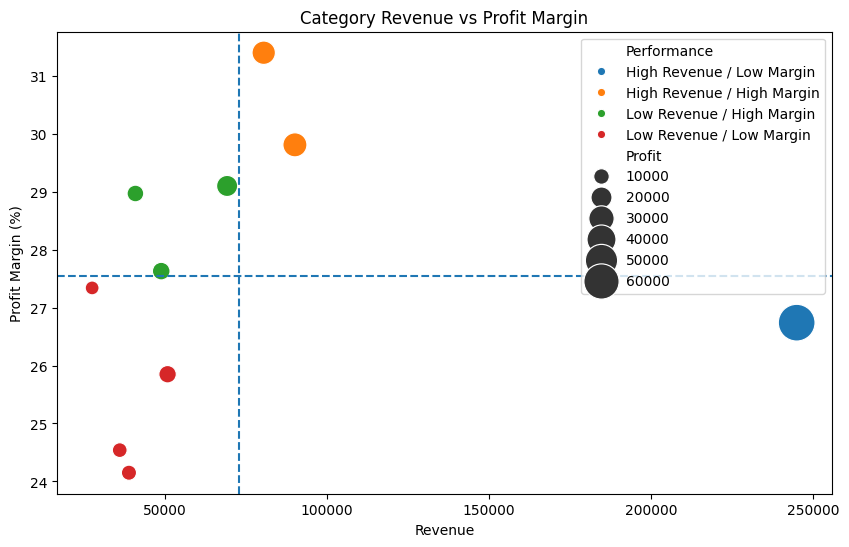

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=category_quadrant,
    x="Revenue",
    y="ProfitMargin",
    size="Profit",
    hue="Performance",
    sizes=(100, 700)
)

plt.axvline(avg_revenue, linestyle="--")
plt.axhline(avg_margin, linestyle="--")

plt.title("Category Revenue vs Profit Margin")
plt.xlabel("Revenue")
plt.ylabel("Profit Margin (%)")

plt.show()


*   Meat & Poultry generated the highest realized revenue, contributing 33.63% of total revenue.

*   Household Cleaning recorded the highest profit margin among categories at 31.40%.

* Discount levels above 30% were associated with a negative profit margin of -15.90%, indicating a potential margin risk from aggressive discounting.

In [ ]:
# ============================================================
# FINAL ANALYTICAL DATASET FOR POWER BI
# ============================================================

final_query = """
SELECT
    -- Order information
    o.OrderID,
    o.OrderDate,
    o.OrderTime,

    -- Customer information
    c.CustomerID,
    c.Gender,
    c.Age,
    c.City,
    c.Region,
    c.CustomerSegment,
    c.SignUpDate,

    -- Product information
    p.ProductID,
    p.ProductName,
    cat.CategoryID,
    cat.CategoryName,

    -- Transaction information
    od.Quantity,
    od.UnitCost,
    od.UnitPrice,
    od.DiscountRate,

    -- Return information
    od.IsReturned,
    od.ReturnDate,
    od.ReturnTime,
    od.ReturnReason,

    -- Sales metrics
    od.Quantity * od.UnitPrice AS GrossSales,

    od.Quantity * od.UnitPrice * od.DiscountRate
        AS DiscountAmount,

    od.Quantity * od.UnitPrice * (1 - od.DiscountRate)
        AS NetSales,

    -- Cost
    od.Quantity * od.UnitCost
        AS TotalCost,

    -- Profit before return adjustment
    (
        od.Quantity * od.UnitPrice * (1 - od.DiscountRate)
        - od.Quantity * od.UnitCost
    ) AS Profit,

    -- Realized metrics
    CASE
        WHEN od.IsReturned = 0 THEN
            od.Quantity * od.UnitPrice * (1 - od.DiscountRate)
        ELSE 0
    END AS RealizedRevenue,

    CASE
        WHEN od.IsReturned = 0 THEN
            (
                od.Quantity * od.UnitPrice * (1 - od.DiscountRate)
                - od.Quantity * od.UnitCost
            )
        ELSE 0
    END AS RealizedProfit,

    -- Net quantity after returns
    CASE
        WHEN od.IsReturned = 0 THEN od.Quantity
        ELSE 0
    END AS NetQuantity

FROM orders AS o

INNER JOIN customers AS c
    ON o.CustomerID = c.CustomerID

INNER JOIN order_details AS od
    ON o.OrderID = od.OrderID

INNER JOIN products AS p
    ON od.ProductID = p.ProductID

INNER JOIN categories AS cat
    ON p.CategoryID = cat.CategoryID
"""

# Execute SQL query
powerbi_df = pd.read_sql_query(final_query, conn)

# Display basic information
print(f"Rows    : {len(powerbi_df):,}")
print(f"Columns : {len(powerbi_df.columns)}")

display(powerbi_df.head())

Rows    : 30,271
Columns : 30


,OrderID,OrderDate,OrderTime,CustomerID,Gender,Age,City,Region,CustomerSegment,SignUpDate,ProductID,ProductName,CategoryID,CategoryName,Quantity,UnitCost,UnitPrice,DiscountRate,IsReturned,ReturnDate,ReturnTime,ReturnReason,GrossSales,DiscountAmount,NetSales,TotalCost,Profit,RealizedRevenue,RealizedProfit,NetQuantity
0,ORD00001,2021-04-10 00:00:00,12:53:24.000000,CSTMR0983,Male,59,Istanbul,Marmara,Standard,2020-10-20 00:00:00,PRDCT0056,VWX's Salted Pretzels,CTGRY0006,Snacks,3,2.14,3.38,0.00,0,None,00:00:00.000000,None,10.14,0.00,10.14,6.42,3.72,10.14,3.72,3
1,ORD00002,2024-04-21 00:00:00,22:08:16.000000,CSTMR0703,Female,47,Istanbul,Marmara,Standard,2020-11-06 00:00:00,PRDCT0001,ABC's Beef Ribeye,CTGRY0001,Meat & Poultry,13,20.36,25.77,0.05,0,None,00:00:00.000000,None,335.01,16.75,318.26,264.68,53.58,318.26,53.58,13
2,ORD00002,2024-04-21 00:00:00,22:08:16.000000,CSTMR0703,Female,47,Istanbul,Marmara,Standard,2020-11-06 00:00:00,PRDCT0028,XYZ's Broccoli Crowns,CTGRY0003,Produce,2,4.17,5.31,0.00,0,None,00:00:00.000000,None,10.62,0.00,10.62,8.34,2.28,10.62,2.28,2
3,ORD00003,2022-10-27 00:00:00,10:21:26.000000,CSTMR0920,Male,34,Ankara,Central Anatolia,Standard,2022-04-15 00:00:00,PRDCT0030,ABC's Blueberries,CTGRY0003,Produce,2,0.90,1.35,0.00,0,None,00:00:00.000000,None,2.70,0.00,2.70,1.80,0.90,2.70,0.90,2
4,ORD00004,2025-11-07 00:00:00,22:24:27.000000,CSTMR0158,Male,35,Ankara,Central Anatolia,VIP,2021-01-08 00:00:00,PRDCT0003,KLM's Turkey Breast,CTGRY0001,Meat & Poultry,3,12.84,20.35,0.00,0,None,00:00:00.000000,None,61.05,0.00,61.05,38.52,22.53,61.05,22.53,3


In [ ]:
# ============================================================
# FINAL KPI VALIDATION
# ============================================================

final_kpi = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Gross Profit",
        "Profit Margin",
        "Total Orders",
        "Total Customers",
        "Gross Quantity",
        "Net Quantity",
        "Returned Items",
        "Return Rate",
        "Average Order Value"
    ],
    "Value": [
        powerbi_df["RealizedRevenue"].sum(),
        powerbi_df["RealizedProfit"].sum(),
        (
            powerbi_df["RealizedProfit"].sum()
            / powerbi_df["RealizedRevenue"].sum()
            * 100
        ),
        powerbi_df["OrderID"].nunique(),
        powerbi_df["CustomerID"].nunique(),
        powerbi_df["Quantity"].sum(),
        powerbi_df["NetQuantity"].sum(),
        powerbi_df["IsReturned"].sum(),
        (
            powerbi_df["IsReturned"].sum()
            / len(powerbi_df)
            * 100
        ),
        (
            powerbi_df["RealizedRevenue"].sum()
            / powerbi_df["OrderID"].nunique()
        )
    ]
})

final_kpi

,Metric,Value
0,Total Revenue,"728,473.12"
1,Gross Profit,"202,204.37"
2,Profit Margin,27.76
3,Total Orders,"10,000.00"
4,Total Customers,"1,000.00"
5,Gross Quantity,"81,166.00"
6,Net Quantity,"77,349.00"
7,Returned Items,"1,424.00"
8,Return Rate,4.70
9,Average Order Value,72.85


In [ ]:
financial_columns = [
    "GrossSales",
    "DiscountAmount",
    "NetSales",
    "TotalCost",
    "Profit",
    "RealizedRevenue",
    "RealizedProfit"
]

powerbi_df[financial_columns] = (
    powerbi_df[financial_columns].round(2)
)

In [ ]:
powerbi_df[
    financial_columns
].head(20)

,GrossSales,DiscountAmount,NetSales,TotalCost,Profit,RealizedRevenue,RealizedProfit
0,10.14,0.00,10.14,6.42,3.72,10.14,3.72
1,335.01,16.75,318.26,264.68,53.58,318.26,53.58
2,10.62,0.00,10.62,8.34,2.28,10.62,2.28
3,2.70,0.00,2.70,1.80,0.90,2.70,0.90
4,61.05,0.00,61.05,38.52,22.53,61.05,22.53
5,63.90,0.00,63.90,40.68,23.22,63.90,23.22
6,18.00,0.00,18.00,14.20,3.80,18.00,3.80
7,9.44,0.00,9.44,6.60,2.84,9.44,2.84
8,7.50,0.00,7.50,5.28,2.22,7.50,2.22
9,58.08,17.42,40.66,45.90,-5.24,40.66,-5.24


In [ ]:
powerbi_df[financial_columns].describe()

,GrossSales,DiscountAmount,NetSales,TotalCost,Profit,RealizedRevenue,RealizedProfit
count,"30,271.00","30,271.00","30,271.00","30,271.00","30,271.00","30,271.00","30,271.00"
mean,26.16,0.99,25.17,18.18,6.99,24.07,6.68
std,46.66,4.86,44.63,32.53,13.06,44.23,12.92
min,1.17,0.00,0.94,0.82,-30.02,0.00,-30.02
25%,7.44,0.00,7.08,5.17,1.72,6.31,1.52
50%,14.24,0.00,13.70,9.88,3.62,12.93,3.38
75%,27.70,0.36,26.86,19.48,7.46,25.71,7.16
max,"1,082.64",226.02,"1,082.64",721.82,387.36,"1,082.64",387.36


In [ ]:
print("Max RealizedRevenue:", powerbi_df["RealizedRevenue"].max())
print("Max RealizedProfit:", powerbi_df["RealizedProfit"].max())
print("Total Revenue:", powerbi_df["RealizedRevenue"].sum())
print("Total Profit:", powerbi_df["RealizedProfit"].sum())

Max RealizedRevenue: 1082.64
Max RealizedProfit: 387.36
Total Revenue: 728473.2300000001
Total Profit: 202204.33000000002


In [ ]:
total_revenue = powerbi_df["RealizedRevenue"].sum()
total_profit = powerbi_df["RealizedProfit"].sum()

print("Total Revenue :", round(total_revenue, 2))
print("Total Profit  :", round(total_profit, 2))
print("Profit Margin :", round(total_profit / total_revenue * 100, 2))

Total Revenue : 728473.23
Total Profit  : 202204.33
Profit Margin : 27.76


In [ ]:
output_file = "retail_analytical_dataset.csv"

powerbi_df.to_csv(
    output_file,
    index=False
)

print(f"File exported successfully: {output_file}")

File exported successfully: retail_analytical_dataset.csv


In [ ]:
from google.colab import files

files.download(output_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>